In [ ]:
# Import Dataset from Google Drive
# Mount at Google Drive to gain access more easily in the future
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Umact_hackathon_dkyet/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Umact_hackathon_dkyet


## **Data Preprocessing**

In [ ]:
# import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Read the dataset
df = pd.read_csv("UMACT_HACKATHON_2026_FINALVERSION.csv")

In [ ]:
# Get insights from the dataset
df.head(5)

,claim_id,policyholder_id,patient_age,patient_gender,smoker_status,bmi,chronic_conditions,has_previous_claims,plan_type,room_and_board_limit,...,procedure_diagnosis,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid,hits_cap
0,MHC0000001,PH02843,4,F,Non-Smoker,27.1,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1555.25,3393.28,1272.48,848.32,7069.33,1750,1413.87,5655.46,False
1,MHC0000002,PH07593,33,M,Non-Smoker,15.2,0,0,Basic,150,...,Asthma Exacerbation,6179.34,13482.19,5055.82,3370.55,28087.90,750,3000.00,25087.90,True
2,MHC0000003,PH00983,1,M,Non-Smoker,27.6,0,0,Basic,150,...,Asthma Exacerbation,6789.39,14813.21,5554.95,3703.30,30860.85,900,3000.00,27860.85,True
3,MHC0000004,PH03707,33,F,Non-Smoker,30.2,0,0,Silver,250,...,Normal Delivery,6137.88,13391.75,5021.90,3347.94,27899.47,750,3000.00,24899.47,True
4,MHC0000005,PH05756,17,M,Non-Smoker,30.4,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1379.66,3010.17,1128.81,752.54,6271.18,1400,1254.24,5016.94,False


In [ ]:
# Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name         20000 non-null  object 
 13  hospital_type         20000 non-null  object 
 14  admission_type        20000 non-null  object 
 15  admission_date     

In [ ]:
# Get insight of central tendency and statistical value
df.describe()

,patient_age,bmi,chronic_conditions,has_previous_claims,room_and_board_limit,length_of_stay,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19700.000000,20000.000000,20000.000000,20000.000000,19560.000000,20000.000000,20000.00000,19400.000000,20000.000000
mean,41.810350,27.094455,1.010650,0.568250,259.240000,5.289391,12932.382046,28216.106208,10581.039794,7046.988376,58783.554600,1379.04000,2765.943685,56018.296644
std,24.526397,6.176665,1.129469,0.495332,121.038651,2.096330,12629.930747,27556.212625,10333.579744,6888.599356,57408.776245,876.63225,535.185731,57202.072675
min,0.000000,12.000000,0.000000,0.000000,150.000000,-10.000000,905.870000,1976.430000,741.160000,494.110000,4117.570000,150.00000,823.510000,3294.060000
25%,20.000000,23.200000,0.000000,0.000000,150.000000,4.000000,4730.850000,10321.865000,3870.695000,2575.740000,21503.877500,750.00000,3000.000000,18503.877500
50%,42.000000,26.700000,1.000000,1.000000,250.000000,5.000000,7109.970000,15512.655000,5817.245000,3875.010000,32318.035000,1200.00000,3000.000000,29318.035000
75%,63.000000,30.500000,2.000000,1.000000,350.000000,7.000000,19652.085000,42877.285000,16078.982500,10702.247500,89327.670000,1750.00000,3000.000000,86327.670000
max,84.000000,65.000000,4.000000,1.000000,550.000000,14.000000,55000.000000,120000.000000,45000.000000,30000.000000,250000.000000,6600.00000,3000.000000,247000.000000


In [ ]:
# Check the number of each missing value in each column
df.isna().sum()

,0
claim_id,0
policyholder_id,0
patient_age,0
patient_gender,0
smoker_status,0
bmi,0
chronic_conditions,0
has_previous_claims,0
plan_type,0
room_and_board_limit,0


In [ ]:
# Check whether there are any duplicated row in the dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# Filling in null values for major_category by inferring the values of sub_category and procedure_diagnosis
mapping = (
    df[df['major_category'].notna()]
    .groupby(['sub_category', 'procedure_diagnosis'])['major_category']
    .agg(lambda x: x.mode()[0])  # most frequent value
)

def fill_major(row):
    if pd.isna(row['major_category']):
        key = (row['sub_category'], row['procedure_diagnosis'])
        return mapping.get(key, np.nan)
    return row['major_category']

df['major_category'] = df.apply(fill_major, axis=1)

# Filling in null values in the investigation_cost by applying the formula investigation_cost = total_claim_amount - doctor_fees - hospital_charges - medication_cost
df['investigation_cost'] = df['investigation_cost'].fillna(
    df['total_claim_amount']
    - df['doctor_fees']
    - df['hospital_charges']
    - df['medication_cost']
)

# Filling in null values in the patient_co_payment by applying the formula, patient_co_payment = total_claim_amount * 0.2, capped at RM3000
df['patient_co_payment'] = df['patient_co_payment'].fillna(
    df['total_claim_amount'] * 0.2).clip(upper=3000)

# Filling in null values in the length_of_stay by referring the formula, length_of_stay = rb_entitlement_total/room_and_board_limit
df['length_of_stay'] = df['length_of_stay'].fillna(
    df['rb_entitlement_total'] / df['room_and_board_limit']
)

# Filling in the null values in the discharge_date by referring the formula, discharge_date = admission_date + length_of_stay
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

df.loc[df['discharge_date'].isna(), 'discharge_date'] = (
    df['admission_date'] + pd.to_timedelta(df['length_of_stay'], unit='D')
)

df.isna().sum()

,0
claim_id,0
policyholder_id,0
patient_age,0
patient_gender,0
smoker_status,0
bmi,0
chronic_conditions,0
has_previous_claims,0
plan_type,0
room_and_board_limit,0


In [ ]:
# From the dataset, if the length_of_stay is negative, switch the value of admission_date and discharge_date and change the negative value to positive
mask = df['length_of_stay'] < 0

df.loc[mask, ['admission_date', 'discharge_date']] = df.loc[mask, ['discharge_date', 'admission_date']].values

df.loc[mask, 'length_of_stay'] = df.loc[mask, 'length_of_stay'].abs()

## **Exploratory Data Analysis (EDA)**

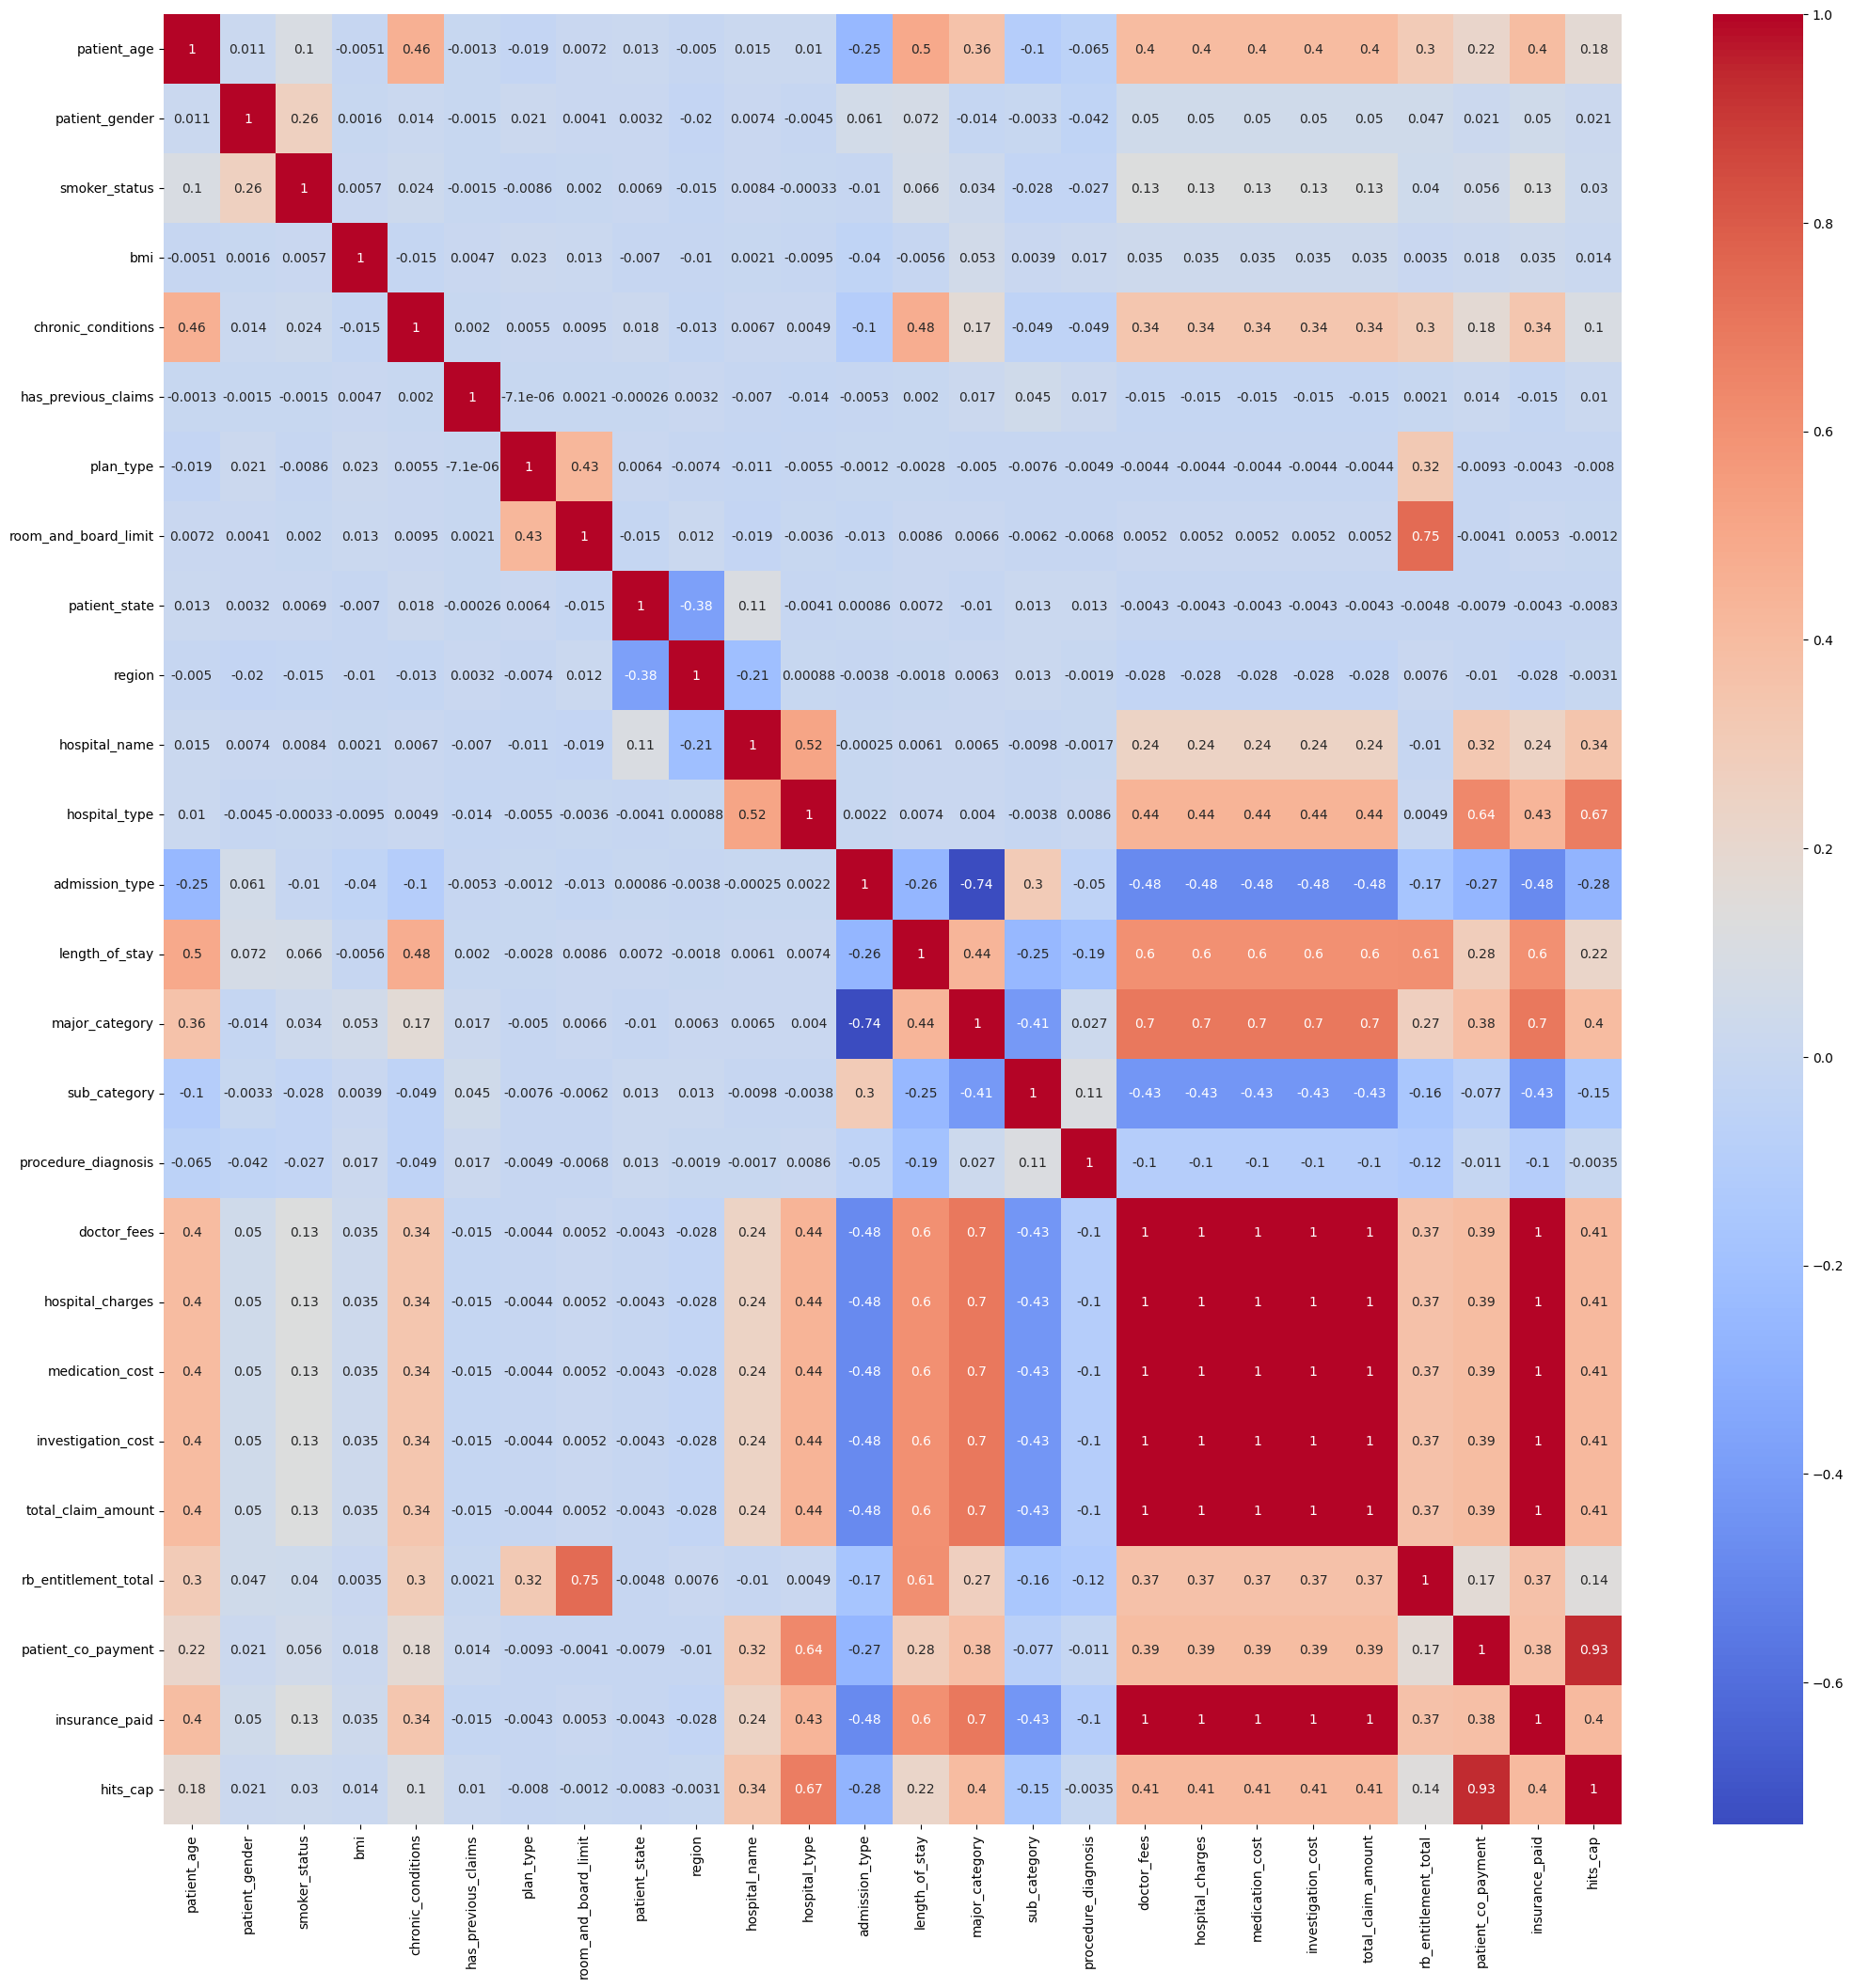

In [ ]:
# Correlation matrix

# Create a copy
df_processed = df.copy()

# Drop IDs
df_processed = df_processed.drop(['claim_id', 'policyholder_id'], axis=1)

# Convert boolean
df_processed['hits_cap'] = df_processed['hits_cap'].astype(int)

df_processed['patient_gender'] = df_processed['patient_gender'].map({
    'M': 1,
    'F': 0
})

df_processed['smoker_status'] = df_processed['smoker_status'].map({
    'Smoker': 1,
    'Non-Smoker': 0
})

from sklearn.preprocessing import LabelEncoder

cols = [
    'plan_type',
    'patient_state',
    'region',
    'hospital_name',
    'hospital_type',
    'admission_type',
    'major_category',
    'sub_category',
    'procedure_diagnosis'
]

le = LabelEncoder()

for col in cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Drop date columns
df_processed = df_processed.drop(['admission_date', 'discharge_date'], axis=1)

# Heatmap
plt.figure(figsize=(25,25))
sns.heatmap(df_processed.corr(), annot = True, cmap='coolwarm')
plt.show()



The strong correlations among cost-related variables indicate multicollinearity, as these features capture overlapping information about total medical expenses. This suggests redundancy in the dataset, where multiple variables represent different components of the same underlying cost structure.

In [ ]:
from matplotlib.ticker import FuncFormatter
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")
def comma_format(x, pos):
    return f'{x:,.0f}'
formatter = FuncFormatter(comma_format)

In [ ]:
bins = [0, 17, 35, 50, 65, float('inf')]
labels = ["Child (0-17)", "Young Adult (18-35)", "Middle Age (36-50)", "Senior (51-65)", "Elderly (66+)"]

df['age_group'] = pd.cut(
    df['patient_age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True)

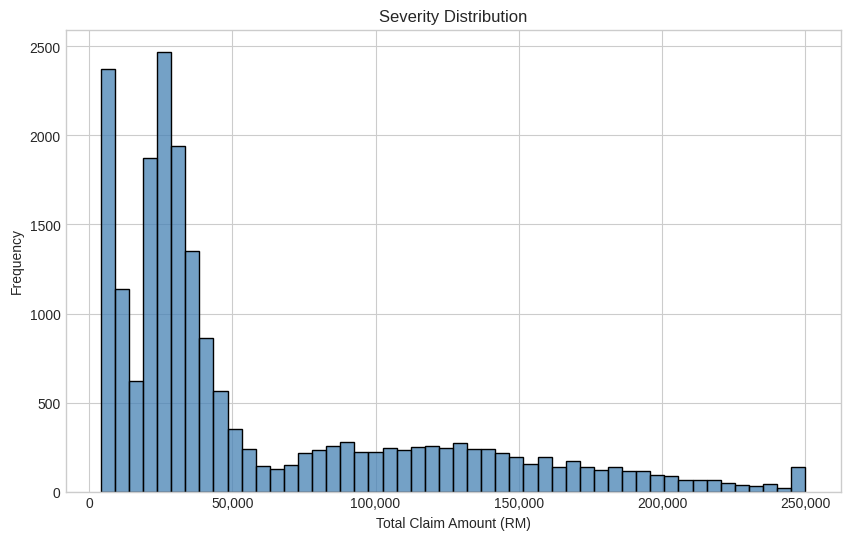

In [ ]:
# Claim severity distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['total_claim_amount'], bins=50, color='steelblue', kde=False)
plt.gca().xaxis.set_major_formatter(formatter)
plt.title("Severity Distribution")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Frequency")
plt.show()

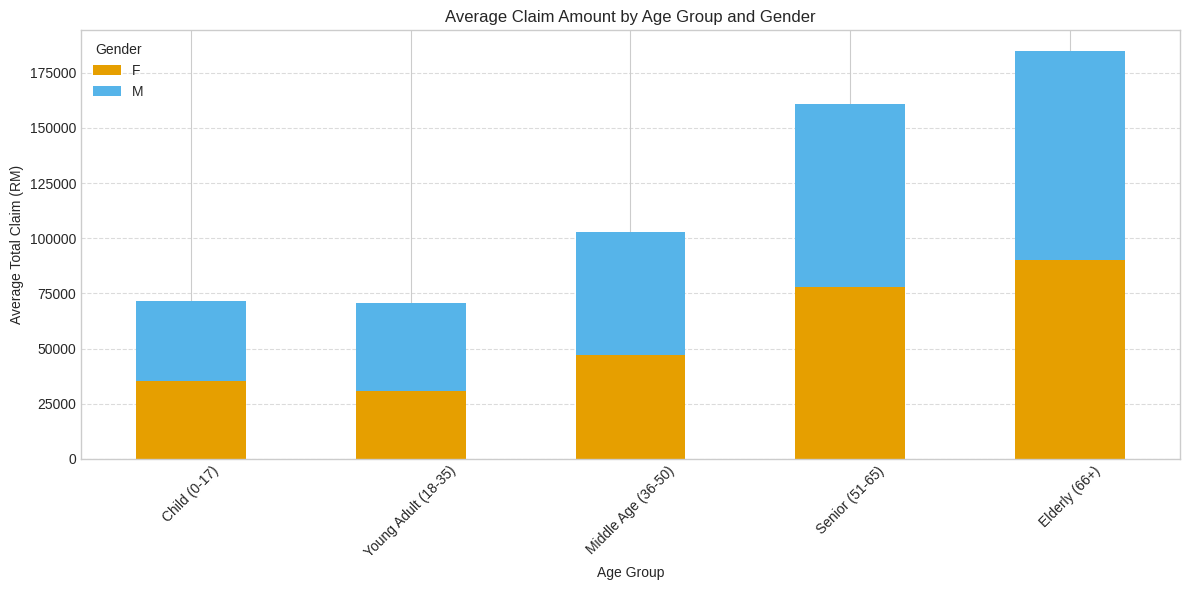

In [ ]:
# Demographic Trends
plt.figure(figsize=(12, 6))
demo_summary = df.groupby(['age_group', 'patient_gender'], observed=False)['total_claim_amount'].mean().unstack()
demo_summary.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#E69F00', '#56B4E9'])
plt.title("Average Claim Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Total Claim (RM)")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

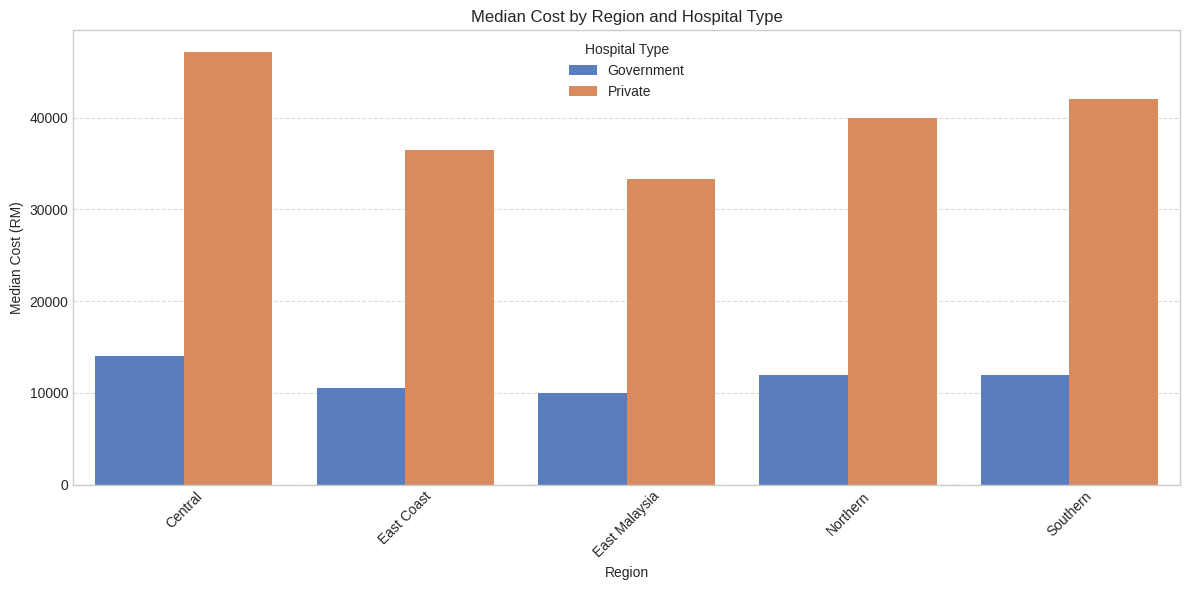

In [ ]:
# Regional brenchmark
regional_summary = df.groupby(['region', 'hospital_type'], observed=False).agg(
    avg_cost=('total_claim_amount', 'mean'),
    median_cost=('total_claim_amount', 'median'),
    count=('total_claim_amount', 'size')).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=regional_summary,
    x='region',
    y='median_cost',
    hue='hospital_type',
    palette="muted")
plt.title("Median Cost by Region and Hospital Type")
plt.xlabel("Region")
plt.ylabel("Median Cost (RM)")
plt.xticks(rotation=45)
plt.legend(title="Hospital Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

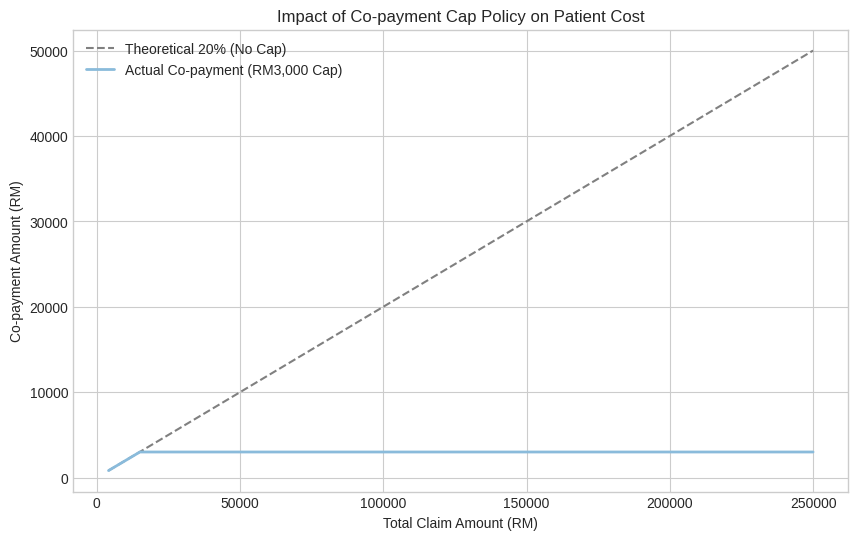

In [ ]:
# Co-payment Cap Policy Impact
plt.figure(figsize=(10, 6))
sns.lineplot(x='total_claim_amount', y=df['total_claim_amount'] * 0.2, data=df,
             label='Theoretical 20% (No Cap)', linestyle='--', color='gray')
sns.lineplot(x='total_claim_amount', y=df['patient_co_payment'], data=df,
             label='Actual Co-payment (RM3,000 Cap)', linewidth=2)
plt.title("Impact of Co-payment Cap Policy on Patient Cost")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Co-payment Amount (RM)")
plt.legend()
plt.show()